<a href="https://www.kaggle.com/code/samratrm/clustering-analysis-of-scaler-learners?scriptVersionId=343490011" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Uncovering Career Archetypes: A Clustering Analysis of Scaler Learners

## Problem Statement

Scaler is an online tech-versity offering intensive computer science & Data Science courses through live classes delivered by tech leaders and subject matter experts. The meticulously structured program enhances the skills of software professionals by offering a modern curriculum with exposure to the latest technologies. It is a product by InterviewBit.

You are working as a data scientist with the analytics vertical of Scaler, focused on profiling the best companies and job positions to work for from the Scaler database. You are provided with the information for a segment of learners and tasked to cluster them on the basis of their job profile, company, and other features. Ideally, these clusters should have similar characteristics.

## Data Understanding

The project uses two files to analyze the learners. The main students job profile file contains anonymized personal identifiers, company identifiers, employment start years, current compensation, job titles, and the year the compensation was last updated. The second file is a job positions mapping table, which is required to clean and standardize the messy, raw job titles from the main dataset into consistent categories for accurate clustering.

#### Data Dictionary `scaler_hashed_for_students.csv`: 

- `Unnamed 0` - Index of the dataset
- `Email_hash` - Anonymised Personal Identifiable Information (PII)
- `Company_hash` - This represents an anonymized identifier for the company, which is the current employer of the learner.
- `orgyear` - Employment start date
- `CTC` - Current CTC
- `Job_position` - Job profile in the company
- `CTC_updated_year` - Year in which CTC got updated (Yearly increments, Promotions)

#### Data Dictionary `scaler_job_positions_mapping VX.csv`:

`Original` - The raw, unstandardized job titles as originally entered by the learners.
`New` - The cleaned and standardized job position categories mapped from the original titles to ensure consistency for clustering.

## Objective

The objective is to clean the raw learner data, standardize the job titles using the mapping file, and apply machine learning clustering techniques. This will group learners with similar career trajectories, companies, and compensation levels to uncover distinct professional profiles within the Scaler database.

## TODO : Solution Appraoch and What was done 

### Imports and Setup:

In [1]:
import numpy as np
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 
import re
import scipy

In [2]:
job_profile = pd.read_csv("/kaggle/input/datasets/samratrm/scaler-job-profile/scaler_hashed_for_students.csv")
job_position = pd.read_csv("/kaggle/input/datasets/samratrm/scaler-job-profile/scaler_job_positions_mapping VX.csv")

job_profile.shape, job_position.shape

((205843, 7), (801, 2))

In [3]:
job_position.head()

,Original,New
0,7,others
1,91,others
2,737,others
3,857628,others
4,896651,others


In [4]:
job_profile.head()

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0


## Data Understanding & Cleaning

### Column Rename and Data type conversion

In [5]:
print(f"Dataset shapes - Job Profile: {job_profile.shape}, Job Positions: {job_position.shape}")

Dataset shapes - Job Profile: (205843, 7), Job Positions: (801, 2)


In [6]:
job_position = job_position.rename({"Original": "original", "New": "new"},axis=1)
job_position['original'] = job_position['original'].astype('category')
job_position['new'] = job_position['new'].astype('category')

print(job_position.dtypes)
job_position.head()

original    category
new         category
dtype: object


,original,new
0,7,others
1,91,others
2,737,others
3,857628,others
4,896651,others


In [7]:
job_profile = job_profile.drop(columns="Unnamed: 0")
job_profile = job_profile.rename(columns={
    'company_hash': 'company_id',
    'email_hash': 'user_id',
    'orgyear': 'org_year',
    'job_position': 'job_position',
    'ctc_updated_year': 'ctc_updated_year'
})

job_profile["ctc"] = job_profile["ctc"].astype("float")
job_profile["org_year"] = pd.to_numeric(job_profile["org_year"], errors='coerce').astype("Int64")
job_profile['ctc_updated_year'] = pd.to_numeric(job_profile['ctc_updated_year'], errors='coerce').astype('Int64')

job_profile['company_id'] = job_profile['company_id'].astype('category')
job_profile['job_position'] = job_profile['job_position'].astype('category')

print(job_profile.dtypes)
job_profile.head()

company_id          category
user_id               object
org_year               Int64
ctc                  float64
job_position        category
ctc_updated_year       Int64
dtype: object


,company_id,user_id,org_year,ctc,job_position,ctc_updated_year
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016,1100000.0,Other,2020
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018,449999.0,FullStack Engineer,2019
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015,2000000.0,Backend Engineer,2020
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017,700000.0,Backend Engineer,2019
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017,1400000.0,FullStack Engineer,2019


### Mapping `job_position`

In [8]:
job_position_clean = job_profile['job_position'].dropna().astype(str).str.strip().str.lower()

clean_map = dict(
    zip(
        job_position['original'].astype(str).str.strip().str.lower(),
        job_position['new']
    )
)

mapped_series = job_position_clean.map(clean_map).fillna(job_profile['job_position'])

job_profile['job_position'] = mapped_series.reindex(job_profile.index)
job_profile['job_position'] = job_profile['job_position'].astype('category')

job_profile.head()

,company_id,user_id,org_year,ctc,job_position,ctc_updated_year
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016,1100000.0,others,2020
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018,449999.0,fullstack devloper,2019
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015,2000000.0,backend engineer,2020
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017,700000.0,backend engineer,2019
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017,1400000.0,fullstack devloper,2019


### Removing Special characters from `company_id` & `job_position`

In [9]:
has_special_chars = job_profile['company_id'].astype(str).str.contains(r'[^A-Za-z0-9 ]', na=False)

print(f"Total rows with special characters: {has_special_chars.sum()}")
print(f"Percentage of total rows: {has_special_chars.mean() * 100:.2f}%")

# job_profile["company_id"] = (
#     job_profile["company_id"]
#     .astype(str)
#     .str.replace(r'[^A-Za-z0-9 ]+', '', regex=True)
#     .str.strip()
#     .astype('category')
# )
# job_profile["company_id"][:5]

Total rows with special characters: 0
Percentage of total rows: 0.00%


In [10]:
has_special_chars = job_profile['job_position'].astype(str).str.contains(r'[^A-Za-z0-9 ]', na=False)

print(f"Total rows with special characters: {has_special_chars.sum()}")
print(f"Percentage of total rows: {has_special_chars.mean() * 100:.2f}%")

job_profile["job_position"] = (
    job_profile["job_position"]
    .astype(str)
    .str.replace(r'[^A-Za-z0-9 ]+', '', regex=True)
    .str.strip()
    .str.lower()
    .replace(['nan', 'NaN', ''], np.nan)
    .astype('category')
)


job_profile["job_position"][:5]

Total rows with special characters: 678
Percentage of total rows: 0.33%


0                others
1    fullstack devloper
2      backend engineer
3      backend engineer
4    fullstack devloper
Name: job_position, dtype: category
Categories (730, object): ['7', '7033771951', 'abap developer', 'account', ..., 'web engineer', 'webcenter consultant', 'wordpress developer', 'young professional 2']

In [11]:
has_special_chars = job_profile['job_position'].astype(str).str.contains(r'[^A-Za-z0-9 ]', na=False)

print(f"Total rows with special characters: {has_special_chars.sum()}")
print(f"Percentage of total rows: {has_special_chars.mean() * 100:.2f}%")

Total rows with special characters: 0
Percentage of total rows: 0.00%


### Reducing `job_position` Cardinality 

In [12]:
top_job_positions = job_profile["job_position"].value_counts(normalize=True)
print(f"The top {top_job_positions[top_job_positions > 0.001].count()} job_positions covers {top_job_positions[top_job_positions > 0.001].sum()*100:.4f} of user profiles")

The top 21 job_positions covers 98.6371 of user profiles


In [13]:
top_21_positions = job_profile["job_position"].value_counts().head(21).index
job_profile["job_position"] = job_profile["job_position"].apply(
    lambda x: x if x in top_21_positions else "others"
)

job_profile["job_position"] = job_profile["job_position"].astype("category").cat.remove_unused_categories()

job_profile["job_position"].nunique()

21

**Summary:** To maintain high coverage while reducing sparsity, we consolidated low-frequency roles into an "others" category, retaining the top 21 job positions that account for 98.6% of all user profiles.

### Checking for Duplicates

In [14]:
duplicate_rows = job_profile[job_profile.duplicated(keep=False)]
print("Sample Exact Duplicates:")
display(duplicate_rows.head(4))

Sample Exact Duplicates:


,company_id,user_id,org_year,ctc,job_position,ctc_updated_year
325,udwkusy,b6499641243cb653395dff2da3f7125c1df7c11a1e9da7...,2016,3350000.0,others,2020
438,wkwk liufdnwkula fzovslzf,6de3d5f9a63a6d1f4e95d534e75609b4938327da053627...,2020,340000.0,others,2020
2377,mekwbsy,7e2ac7c6b9051177ea51af3f7c8e934d6d3ce15a5cb587...,2020,1300000.0,fullstack devloper,2020
3076,ekohku suwzoukwsiukn,9c65ec470a225aa9a6b11b6a8b46f42189f65d2d12a033...,2019,400000.0,others,2021


In [15]:
job_profile.drop_duplicates(inplace=True)
job_profile.reset_index(drop=True, inplace=True)

print(f"Dataset shape after dropping duplicates: {job_profile.shape}")

Dataset shape after dropping duplicates: (205388, 6)


### Grouping users with multiple entries in the dataset

In [16]:
total_rows = len(job_profile)
unique_users = job_profile['user_id'].nunique()
duplicate_user_count = total_rows - unique_users

print(f"Total Rows: {total_rows}")
print(f"Unique Users: {unique_users}")
print(f"Users with multiple records: {duplicate_user_count} ({duplicate_user_count / total_rows * 100:.2f}%)")

Total Rows: 205388
Unique Users: 153443
Users with multiple records: 51945 (25.29%)


In [17]:
job_profile['job_position'] = job_profile.groupby('user_id')['job_position'].ffill().bfill()
job_profile['company_id'] = job_profile.groupby('user_id')['company_id'].ffill().bfill()

user_career_stats = job_profile.groupby('user_id', as_index=False).agg(
    total_updates=('ctc_updated_year', 'count'),
    min_ctc=('ctc', 'min'),
    max_ctc=('ctc', 'max'),
    min_year=('ctc_updated_year', 'min'),
    max_year=('ctc_updated_year', 'max')
)

user_career_stats['ctc_growth'] = np.where(
    user_career_stats['total_updates'] > 1, 
    user_career_stats['max_ctc'] - user_career_stats['min_ctc'], 
    0.0
)

user_career_stats['career_span_years'] = np.where(
    user_career_stats['total_updates'] > 1, 
    user_career_stats['max_year'] - user_career_stats['min_year'], 
    0
)

user_career_stats.drop(columns=['min_year', 'max_year'], inplace=True)

job_profile_sorted = job_profile.sort_values(
    by=['user_id', 'ctc_updated_year', 'org_year', 'ctc'], 
    ascending=[True, False, False, False]
)

job_profile_clean = job_profile_sorted.drop_duplicates(subset=['user_id'], keep='first').copy()
job_profile_clean = job_profile_clean.merge(user_career_stats, on='user_id', how='left')

job_profile_clean.head()

,company_id,user_id,org_year,ctc,job_position,ctc_updated_year,total_updates,min_ctc,max_ctc,ctc_growth,career_span_years
0,hsloifibw,00003288036a44374976948c327f246fdbdf0778546904...,2012,3500000.0,backend engineer,2019,1,3500000.0,3500000.0,0.0,0
1,wotw cstswkn,0000aaa0e6b61f7636af1954b43d294484cd151c9b3cf6...,2013,250000.0,backend engineer,2020,1,250000.0,250000.0,0.0,0
2,ijwdh,0000d58fbc18012bf6fa2605a7b0357d126ee69bc41032...,2021,1300000.0,backend engineer,2019,2,1300000.0,1300000.0,0.0,0
3,hsloifzhs liojiokwsiu,000120d0c8aa304fcf12ab4b85e21feb80a342cfea03d4...,2004,2000000.0,fullstack devloper,2021,1,2000000.0,2000000.0,0.0,0
4,mknhkow nkgf,00014d71a389170e668ba96ae8e1f9d991591acc899025...,2009,3400000.0,software developer 1,2018,1,3400000.0,3400000.0,0.0,0


In [18]:
100* job_profile_clean["total_updates"].value_counts(normalize=True)

total_updates
1     73.270856
2     21.188976
3      4.334509
4      0.925425
5      0.206591
6      0.059305
7       0.00782
8       0.00391
9      0.001955
10     0.000652
Name: proportion, dtype: Float64

In [19]:
100 * (job_profile_clean["max_ctc"] == job_profile_clean["min_ctc"]).sum() / job_profile_clean.shape[0]

np.float64(93.27763404000183)

In [20]:
job_profile_clean[job_profile_clean["ctc_growth"] > 0 ]["ctc_growth"].median()

320000.0

In [21]:
job_profile_clean["career_span_years"].value_counts(normalize=True)

career_span_years
0    0.939724
1    0.034065
2    0.022301
3    0.001290
4    0.001258
5    0.000880
6    0.000482
Name: proportion, dtype: float64

In [22]:
job_profile_clean["job_position"].isna().sum()

np.int64(4)

**Summary:**

* **26.8%** of learners in the dataset have more than one recorded entry.
* Only **~6.8%** of these multi-entry learners experienced a change in their reported CTC.
* Among learners who saw a salary update, the median CTC increase was **₹320,000**.
* The grouping has also imputed most of the empty `job_position` (~52.5K to 5)

### Sanitizing Invalid `org_year` Values

In [23]:
job_profile_clean["org_year"].value_counts()

org_year
2016    17324
2018    16822
2017    16549
2015    15989
2019    15019
        ...  
1972        1
2027        1
1981        1
83          1
2101        1
Name: count, Length: 77, dtype: Int64

In [24]:
current_year = 2026

job_profile_clean.loc[
    (job_profile_clean['org_year'] < 1970) | (job_profile_clean['org_year'] > current_year), 
    'org_year'
] = np.nan
job_profile_clean["org_year"].value_counts()[:5]

org_year
2016    17324
2018    16822
2017    16549
2015    15989
2019    15019
Name: count, dtype: Int64

## Feature Engineering (Post User Deduplication)

In [25]:
job_profile_clean.columns

Index(['company_id', 'user_id', 'org_year', 'ctc', 'job_position',
       'ctc_updated_year', 'total_updates', 'min_ctc', 'max_ctc', 'ctc_growth',
       'career_span_years'],
      dtype='object')

In [26]:
job_profile_clean["years_of_exp"] = job_profile_clean["ctc_updated_year"] - job_profile_clean["org_year"]
job_profile_clean["ctc_change"] = job_profile_clean["ctc_growth"] > 0

df_user_profile = job_profile_clean[[
    'user_id', 
    'company_id', 
    'job_position', 
    'org_year', 
    'years_of_exp',
    'ctc', 
    'ctc_change', 
    'ctc_updated_year', 
    'total_updates'
]].copy()

df_user_profile.head()

,user_id,company_id,job_position,org_year,years_of_exp,ctc,ctc_change,ctc_updated_year,total_updates
0,00003288036a44374976948c327f246fdbdf0778546904...,hsloifibw,backend engineer,2012,7,3500000.0,False,2019,1
1,0000aaa0e6b61f7636af1954b43d294484cd151c9b3cf6...,wotw cstswkn,backend engineer,2013,7,250000.0,False,2020,1
2,0000d58fbc18012bf6fa2605a7b0357d126ee69bc41032...,ijwdh,backend engineer,2021,-2,1300000.0,False,2019,2
3,000120d0c8aa304fcf12ab4b85e21feb80a342cfea03d4...,hsloifzhs liojiokwsiu,fullstack devloper,2004,17,2000000.0,False,2021,1
4,00014d71a389170e668ba96ae8e1f9d991591acc899025...,mknhkow nkgf,software developer 1,2009,9,3400000.0,False,2018,1


#### Feature Engineering Summary

* **`years_of_exp`**: Calculated as `current_year - org_year` to measure total professional experience in years.
* **`ctc_change`**: Binary indicator (1/0) flagging whether a learner ever received a salary update across their recorded entries.
* **`total_updates`**: Count of total profile updates logged by the learner, serving as an indicator of profile activity.
* **`ctc_updated_year`**: Preserves the most recent year in which the learner updated their compensation details.


### Sanitizing Invalid `years_of_exp` Values

In [27]:
df_user_profile["years_of_exp"].describe()

count    153307.0
mean     4.675983
std      4.251462
min          -8.0
25%           2.0
50%           4.0
75%           6.0
max          51.0
Name: years_of_exp, dtype: Float64

In [28]:
df_user_profile[df_user_profile["years_of_exp"] < 0 ]["years_of_exp"].value_counts()

years_of_exp
-1    5111
-2    1422
-3     360
-4      60
-5      32
-6       3
-7       1
-8       1
Name: count, dtype: Int64

In [29]:
df_user_profile.loc[df_user_profile['years_of_exp'].isin([-1, -2]), 'years_of_exp'] = 0

df_user_profile = df_user_profile[
    (df_user_profile["years_of_exp"] >= -2) |  (df_user_profile["years_of_exp"].isna())
].reset_index(drop=True)

**Handling Negative `years_of_exp`**

Computing `years_of_exp` (`ctc_updated_year - org_year`) yielded negative values for **6,990 learners (4.6%)**, primarily caused by asynchronous profile updates (e.g., entering a future start date or updating job titles without refreshing CTC).

* **Small Negatives (-1 and -2 | 6,533 rows):** Clipped to `0`. These represent new joiners or recent job changes; retaining them avoids underrepresenting early-career learners.
* **Large Negatives (-3 and below | 457 rows):** Dropped. These account for only 0.3% of the dataset and lack a plausible data entry mechanism.

> **Note:** For clipped records, the listed CTC may reflect compensation from the learner's previous employer rather than their new role.

### Missing Data Handling

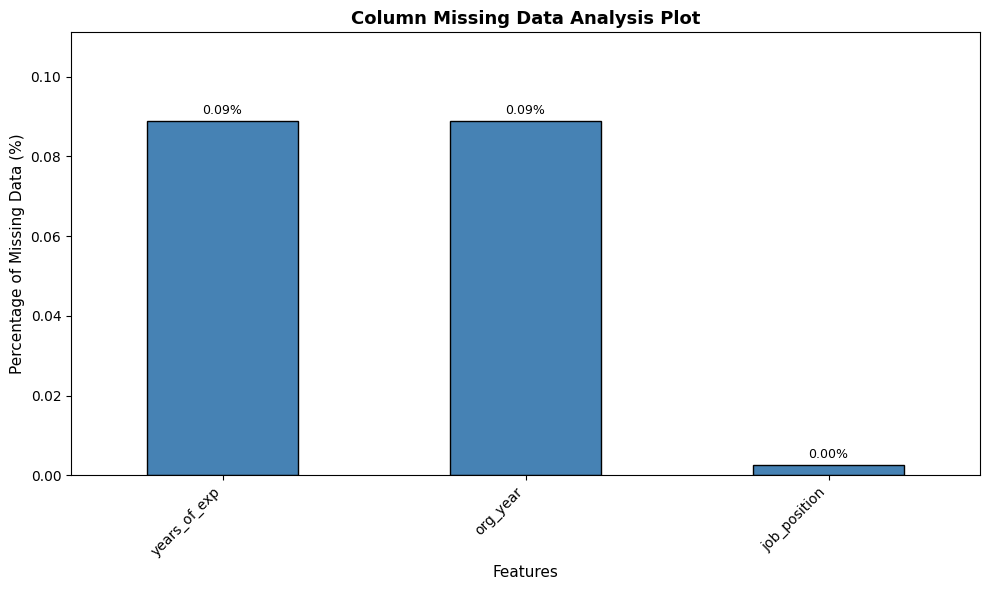

In [30]:
missing_cols = df_user_profile.isna().sum().sort_values(ascending=False)
missing_cols = 100* missing_cols[missing_cols > 0] / df_user_profile.shape[0]

plt.figure(figsize=(10, 6))
ax = missing_cols.plot(kind="bar", color="steelblue", edgecolor="black")

plt.ylim(0, min(missing_cols.max() * 1.25, 100))
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.ylabel("Percentage of Missing Data (%)", fontsize=11)
plt.xlabel("Features", fontsize=11)
plt.title("Column Missing Data Analysis Plot", fontsize=13, fontweight="bold")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                xytext=(0, 3), 
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

In [31]:
df_user_profile = df_user_profile.dropna(axis=0).reset_index(drop=True)

df_user_profile.isna().sum()

user_id             0
company_id          0
job_position        0
org_year            0
years_of_exp        0
ctc                 0
ctc_change          0
ctc_updated_year    0
total_updates       0
dtype: int64

### Sanitizing Invalid `ctc` Values

In [32]:
df_user_profile["ctc"].describe()

count    1.528460e+05
mean     2.508713e+06
std      1.302433e+07
min      2.000000e+00
25%      5.500000e+05
50%      9.900000e+05
75%      1.700000e+06
max      1.000150e+09
Name: ctc, dtype: float64

Log Bounds: [4.56, 7.39]
CTC Bounds (INR): [36620.75, 24827690.38]


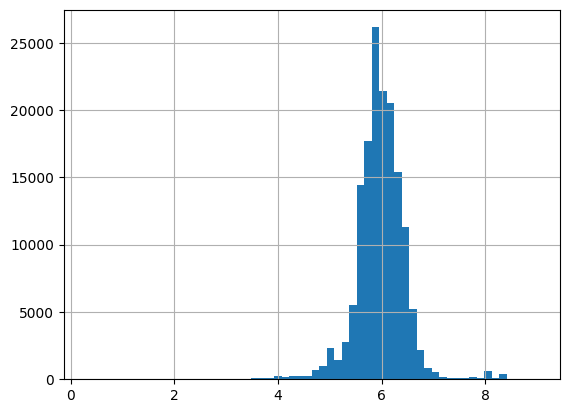

In [33]:
log_ctc = np.log10(df_user_profile["ctc"])
log_ctc.hist(bins=60)

mean_log = log_ctc.mean()
std_log = log_ctc.std()

lower_bound_log = mean_log - (3 * std_log)
upper_bound_log = mean_log + (3 * std_log)

lower_bound_ctc = 10 ** lower_bound_log
upper_bound_ctc = 10 ** upper_bound_log

print(f"Log Bounds: [{lower_bound_log:.2f}, {upper_bound_log:.2f}]")
print(f"CTC Bounds (INR): [{lower_bound_ctc:.2f}, {upper_bound_ctc:.2f}]")

In [34]:
df_user_profile.shape

(152846, 9)

In [35]:
df_user_profile = df_user_profile[
    (log_ctc >= lower_bound_log) & (log_ctc <= upper_bound_log)
].reset_index(drop=True)

df_user_profile.shape

(149878, 9)

#### **Summary:**

* We filtered out extreme CTC outliers outside the $3\sigma$ range on the $\log_{10}$ scale (values under ₹36.6K and above ₹2.48Cr) to sanitize impossible data entries prior to analysis.
* Note that this step is basic statistical data sanitization to clean corrupted entries; formal machine learning anomaly detection for subtle outlier patterns will be covered in later sections.

In [36]:
df_user_profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149878 entries, 0 to 149877
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   user_id           149878 non-null  object  
 1   company_id        149878 non-null  category
 2   job_position      149878 non-null  category
 3   org_year          149878 non-null  Int64   
 4   years_of_exp      149878 non-null  Int64   
 5   ctc               149878 non-null  float64 
 6   ctc_change        149878 non-null  bool    
 7   ctc_updated_year  149878 non-null  Int64   
 8   total_updates     149878 non-null  Int64   
dtypes: Int64(4), bool(1), category(2), float64(1), object(1)
memory usage: 9.6+ MB


# EDA 

### Numerical Univariate Data Analysis 

In [37]:
print(f"Number of unique user_id: {df_user_profile["user_id"].nunique()} and it is unique to each row :{df_user_profile["user_id"].nunique() == df_user_profile.shape[0]}")

Number of unique user_id: 149878 and it is unique to each row :True


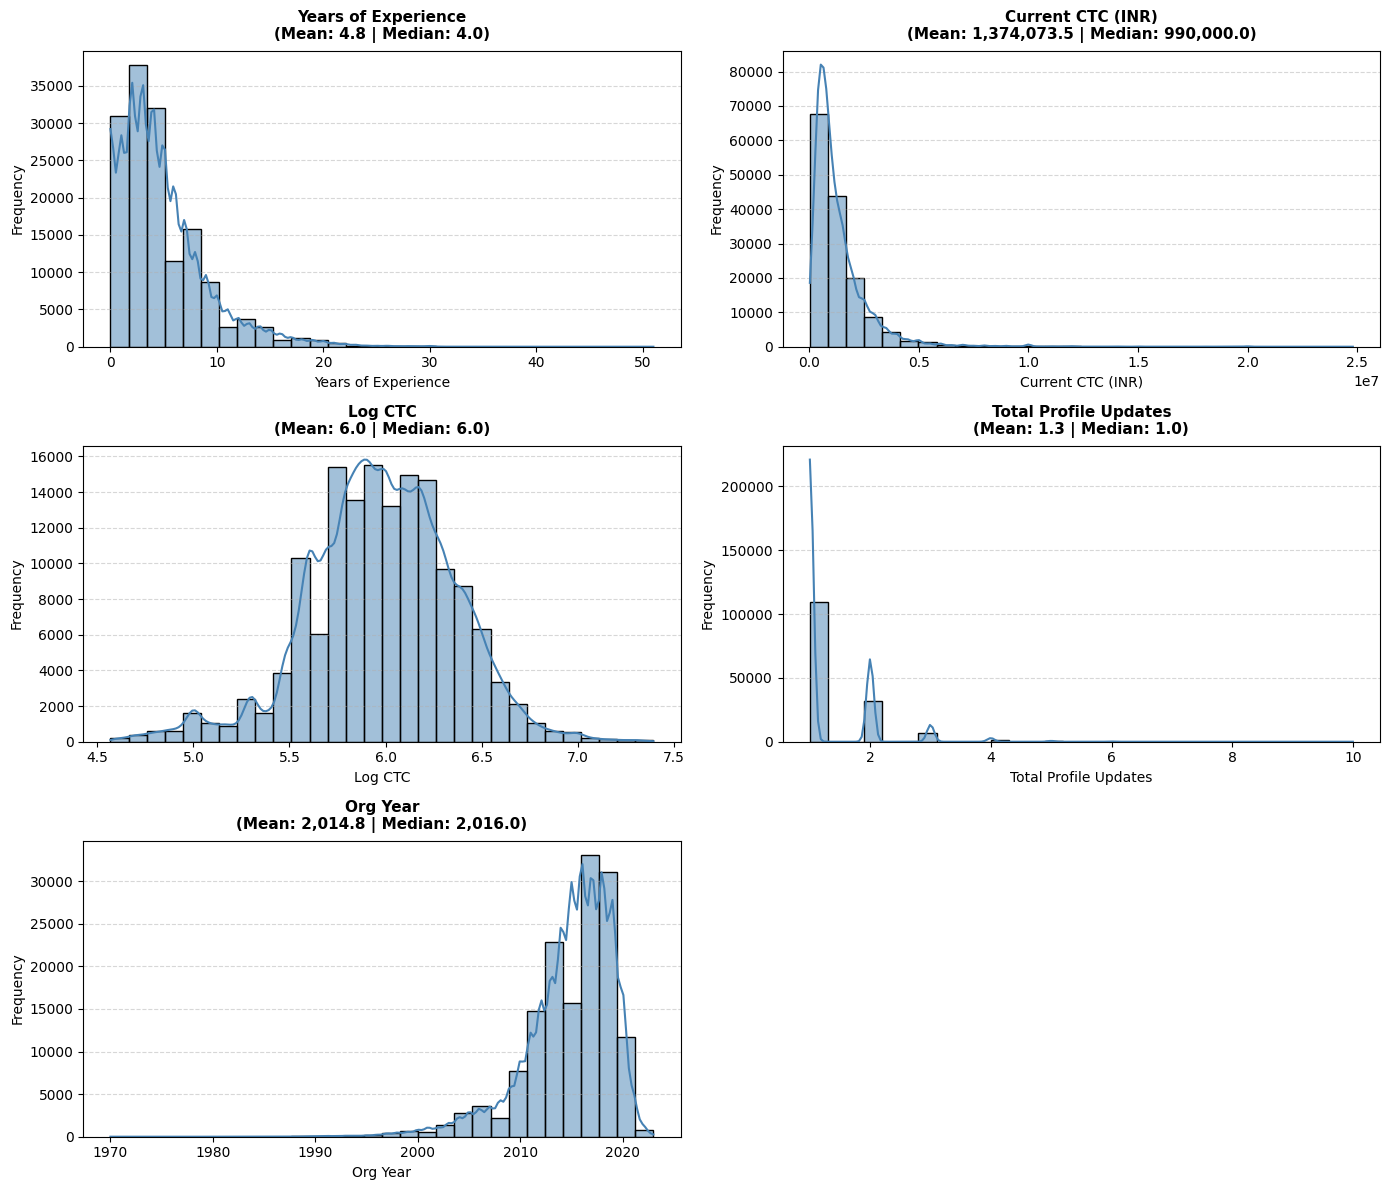

In [38]:
num_feats = ["years_of_exp", "ctc", "ctc_log", "total_updates", "org_year"]

df_user_profile["ctc_log"] = np.log10(df_user_profile["ctc"])

n_cols = 2
n_rows = (len(num_feats) + n_cols-1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
axes = axes.flatten()

feature_titles = {
    "years_of_exp": "Years of Experience",
    "org_year": "Org Year",
    "ctc": "Current CTC (INR)",
    "ctc_log": "Log CTC",
    "total_updates": "Total Profile Updates"
}

for i, col in enumerate(num_feats):
    ax = axes[i]
    data = df_user_profile[col].dropna()
    
    mean_val = data.mean()
    median_val = data.median()
    
    sns.histplot(data, bins=30, kde=True, ax=ax, color="steelblue", edgecolor="black")
    
    title_name = feature_titles.get(col, col.replace("_", " ").title())
    subtitle = f"Mean: {mean_val:,.1f} | Median: {median_val:,.1f}"
    
    ax.set_title(f"{title_name}\n({subtitle})", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel(title_name, fontsize=10)
    ax.set_ylabel("Frequency", fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Categorical Univariate Data Analysis 

In [39]:
cat_feats = ['company_id', 'job_position', 'ctc_change', 'ctc_updated_year']

for feat in cat_feats: 
    print(f"{feat}: {df_user_profile[feat].nunique()}")

cat_feats.remove("company_id")

company_id: 35202
job_position: 21
ctc_change: 2
ctc_updated_year: 7


**Note:** Since, `company_id` is ~35K high cardinality we can use frequency encoding or mean ctc instead of OHE. 

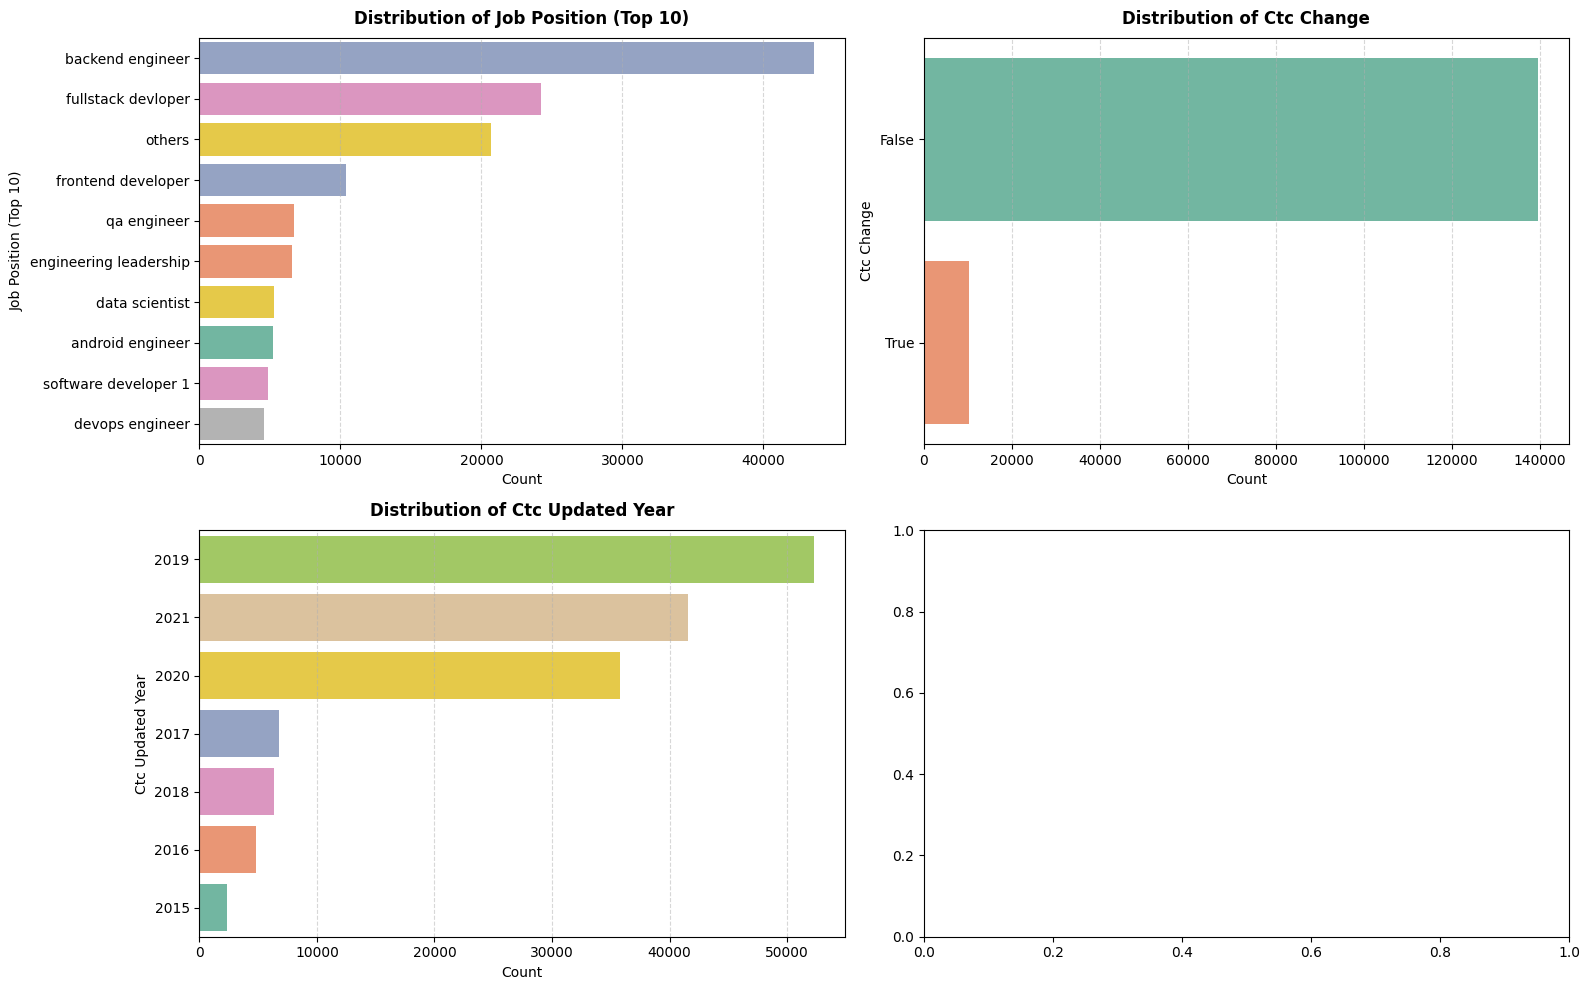

In [40]:
fig, axes = plt.subplots(2,2, figsize=(16,10))
axes = axes.flatten()

for i, col in enumerate(cat_feats):
    ax = axes[i]
    order = df_user_profile[col].value_counts().index
    plot_data = df_user_profile
    
    if col == 'job_position':
        order = order[:10]
        lot_data = df_user_profile[df_user_profile[col].isin(order)].copy()
        plot_data[col] = plot_data[col].cat.remove_unused_categories()
    
    sns.countplot(
        data=plot_data,
        y=col,
        order=order,
        hue=col,
        legend=False,
        ax=ax,
        palette="Set2"
    )
        
    clean_title = col.replace('_', ' ').title()
    if col == 'job_position':
        clean_title += " (Top 10)"
        
    ax.set_title(f"Distribution of {clean_title}", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Count", fontsize=10)
    ax.set_ylabel(clean_title, fontsize=10)
    ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

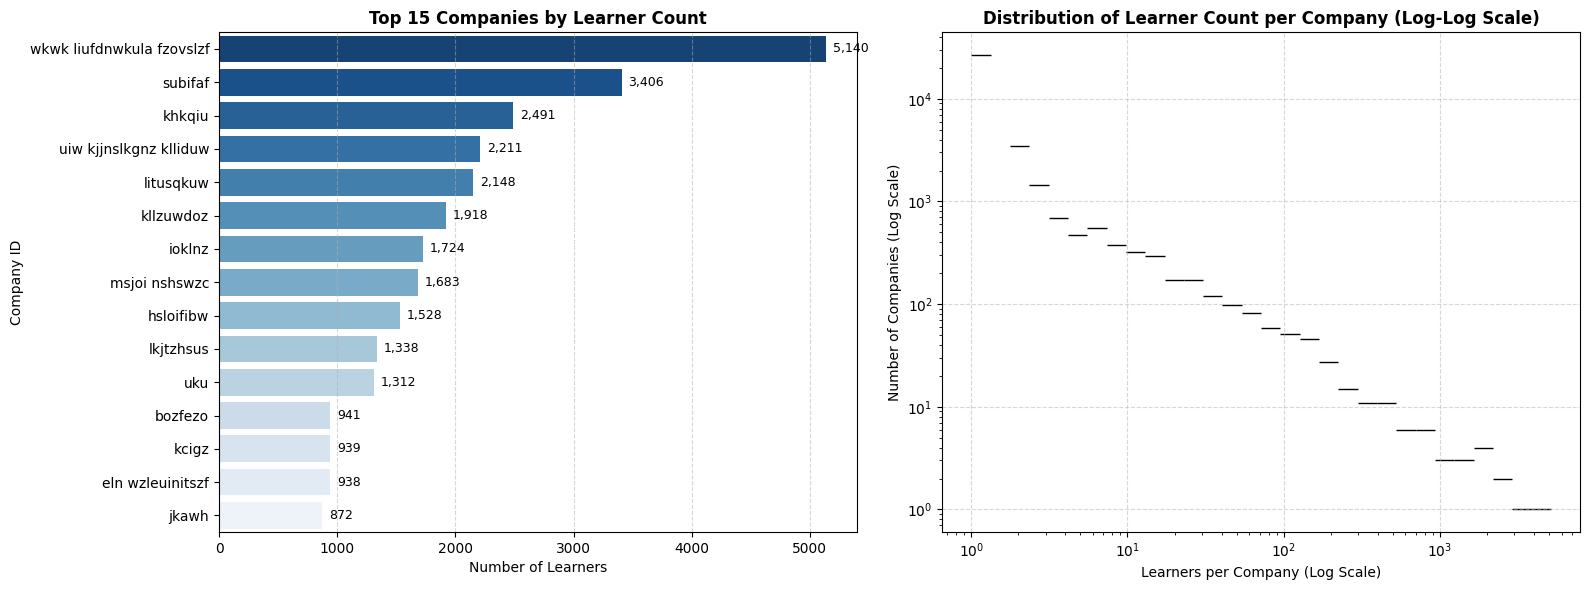

Total Unique Companies: 37,299
Companies with only 1 learner: 26,682 (71.54%)
Top 1% of companies account for: 51.94% of total profiles


In [41]:
company_counts = df_user_profile["company_id"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_15 = company_counts.head(15)
sns.barplot(
    x=top_15.values,
    y=top_15.index.astype(str),
    ax=axes[0],
    palette="Blues_r",
    hue=top_15.index.astype(str),
    legend=False
)
axes[0].set_title("Top 15 Companies by Learner Count", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Learners", fontsize=10)
axes[0].set_ylabel("Company ID", fontsize=10)
axes[0].grid(axis="x", linestyle="--", alpha=0.5)

for p in axes[0].patches:
    axes[0].annotate(
        f"{int(p.get_width()):,}",
        (p.get_width(), p.get_y() + p.get_height() / 2.0),
        ha="left", va="center", xytext=(5, 0), textcoords="offset points", fontsize=9
    )

sns.histplot(
    company_counts.values,
    bins=30,
    log_scale=(True, True),
    ax=axes[1],
    color="steelblue",
    edgecolor="black"
)
axes[1].set_title("Distribution of Learner Count per Company (Log-Log Scale)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Learners per Company (Log Scale)", fontsize=10)
axes[1].set_ylabel("Number of Companies (Log Scale)", fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Print Key Summary Metrics
single_learner_companies = (company_counts == 1).sum()
print(f"Total Unique Companies: {len(company_counts):,}")
print(f"Companies with only 1 learner: {single_learner_companies:,} ({single_learner_companies / len(company_counts) * 100:.2f}%)")
print(f"Top 1% of companies account for: {company_counts.head(int(len(company_counts)*0.01)).sum() / len(df_user_profile) * 100:.2f}% of total profiles")

#### **Univariate Analysis Summary:**

* **Extreme Power-Law Employer Distribution:** Over 71% of companies ($26,682$) appear only once in the dataset, while the top 1% of employers account for **51.9% of all learner profiles**.
* **Concentration in Top Employers:** Talent is heavily clustered around a few dominant tech hubs, led by the top firm with over $5,100$ learners, justifying an "others" binning strategy for downstream modeling.
* **Dominance of Core Engineering Roles:** Job positions are heavily skewed toward core software roles (e.g., Backend, Fullstack, Software Developer), with the top 21 roles capturing **98.6% of the workforce**.
* **Experience & Recency Skew:** Most learners are early-to-mid-career professionals (median experience around 4 years) who updated their profiles recently, showing high engagement among active job seekers or recent upskillers.
* **Salary Skewness & Stability:** CTC exhibits extreme right-skewness spanning several orders of magnitude, though a large majority of multi-entry learners show stable compensation over time with periodic promotional spikes (median increase of ₹3.2L).

## Bivariate Analysis

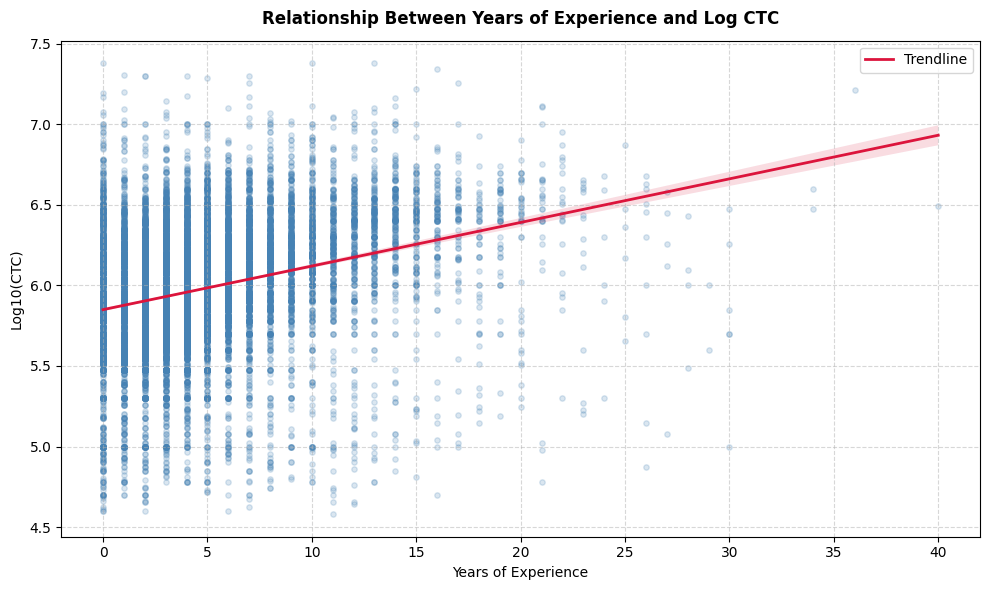

In [42]:
plt.figure(figsize=(10,6))

df_sample = df_user_profile.sample(frac=0.1, random_state=42)

sns.regplot(
    data=df_sample,
    x="years_of_exp",
    y="ctc_log",
    fit_reg=True,
    scatter_kws={"alpha": 0.2, "s": 15, "color": "steelblue"},
    line_kws={"color": "crimson", "linewidth": 2, "label": "Trendline"}
)

plt.title("Relationship Between Years of Experience and Log CTC", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Years of Experience", fontsize=10)
plt.ylabel("Log10(CTC)", fontsize=10)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

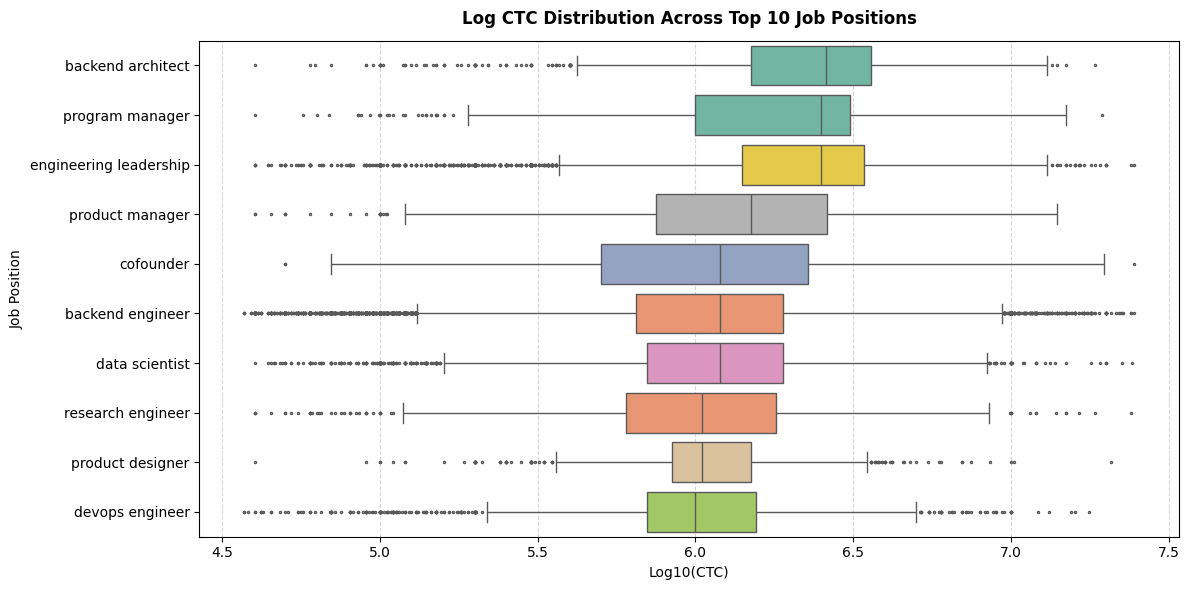

In [43]:
top_10_roles = (
    df_user_profile.groupby("job_position", observed=True)["ctc_log"]
    .median()
    .sort_values(ascending=False)
    .index[:10]
)

df_top10 = df_user_profile[df_user_profile["job_position"].isin(top_10_roles)].copy()
df_top10["job_position"] = df_top10["job_position"].cat.remove_unused_categories()

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_top10,
    y="job_position",
    x="ctc_log",
    order=top_10_roles,
    palette="Set2",
    hue="job_position",
    legend=False,
    fliersize=1.5
)

plt.title("Log CTC Distribution Across Top 10 Job Positions", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Log10(CTC)", fontsize=10)
plt.ylabel("Job Position", fontsize=10)
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

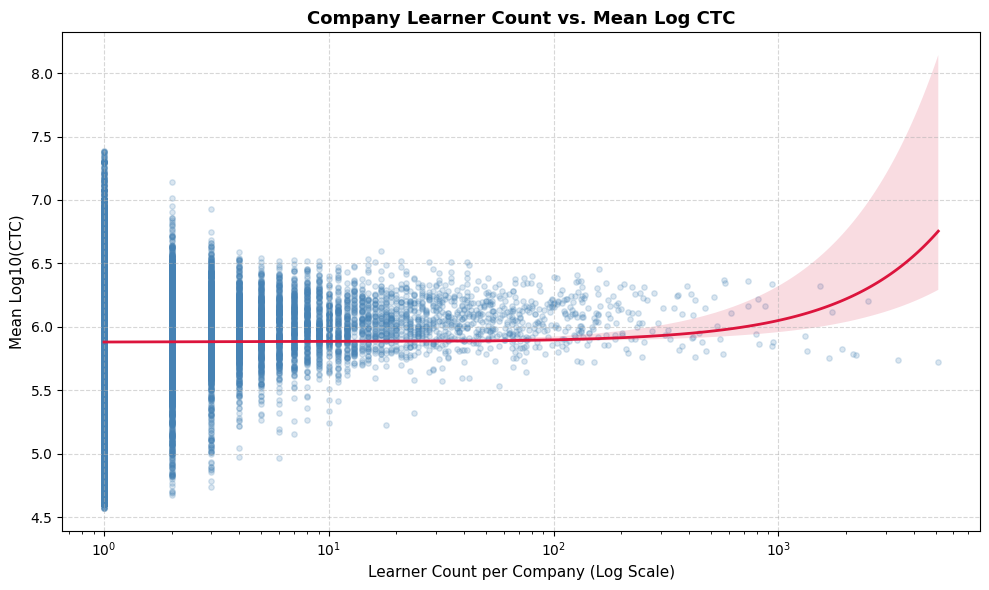

In [44]:
company_stats = (
    df_user_profile.groupby("company_id", observed=True)
    .agg(
        company_count = ("user_id", "count"),
        mean_log_ctc = ("ctc_log", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.regplot(
    data=company_stats,
    x="company_count",
    y="mean_log_ctc",
    fit_reg=True,
    scatter_kws={"alpha": 0.2, "s": 15, "color": "steelblue"},
    line_kws={"color": "crimson", "linewidth": 2, "label": "Trendline"}
)

plt.xscale("log")
plt.title('Company Learner Count vs. Mean Log CTC', fontsize=13, fontweight='bold')
plt.xlabel('Learner Count per Company (Log Scale)', fontsize=11)
plt.ylabel('Mean Log10(CTC)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

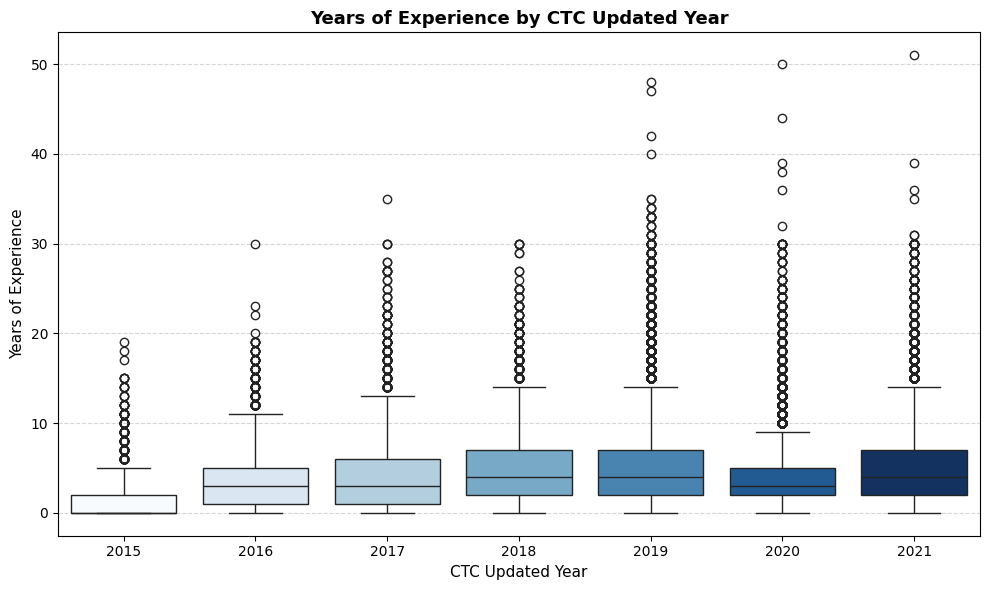

In [45]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_user_profile,
    x='ctc_updated_year',
    y='years_of_exp',
    hue='ctc_updated_year',
    legend=False,
    palette='Blues'
)

plt.title('Years of Experience by CTC Updated Year', fontsize=13, fontweight='bold')
plt.xlabel('CTC Updated Year', fontsize=11)
plt.ylabel('Years of Experience', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()



#### **Bivariate Analysis Summary**

* **Years of Exp vs. Log CTC:** Weak correlation. Compensation varies widely at every experience level, making experience a weak standalone predictor of CTC.
* **Job Position Spread:** Within-role salary variation is larger than the variation between different roles, indicating job title alone does not dictate pay.
* **Company Learner Count vs. CTC:** CTC variance decreases as company size/learner count increases, stabilizing around the company mean.
* **Years of Exp vs. CTC Updated Year:** Earlier update years (2015–2016) skew toward lower median experience, whereas recent updates (2018–2021) cover higher median experience levels.

## Correlation Metrix 

### Numerical Spearman Correlation Matrix 

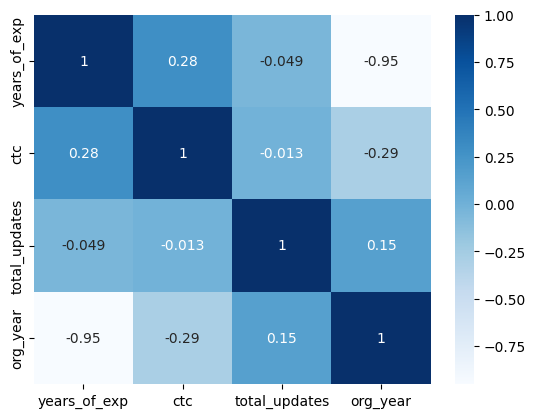

In [46]:
num_feats = ["years_of_exp", "ctc", "total_updates", "org_year"]

corr_matrix = df_user_profile[num_feats].corr()
sns.heatmap(corr_matrix, annot=True, cmap='Blues')
plt.show()

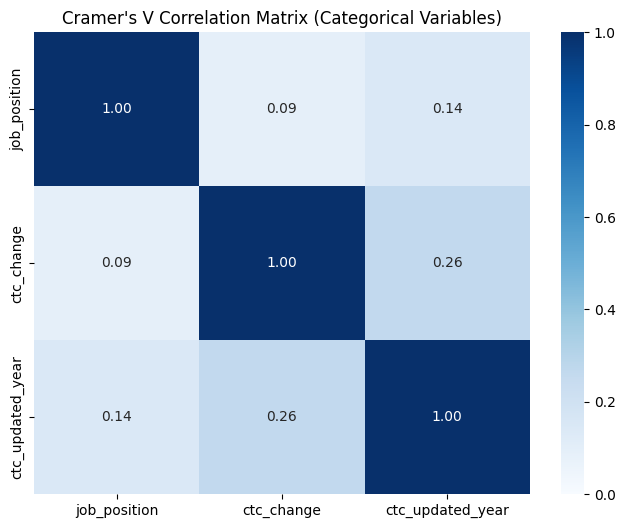

In [47]:
from scipy.stats.contingency import association

cat_feats = ['job_position', 'ctc_change', 'ctc_updated_year']

n = len(cat_feats)
v_matrix = pd.DataFrame(np.zeros((n, n)), index=cat_feats, columns=cat_feats)


for col1 in cat_feats:
    for col2 in cat_feats:
        confusion_matrix = pd.crosstab(df_user_profile[col1], df_user_profile[col2])
        v_matrix.loc[col1, col2] = association(confusion_matrix, method="cramer")

plt.figure(figsize=(8, 6))
sns.heatmap(v_matrix, annot=True, cmap='Blues', vmin=0, vmax=1, fmt=".2f")
plt.title("Cramer's V Correlation Matrix (Categorical Variables)")
plt.show()

#### **Correlation Analysis Summary:**

* **Mathematical Redundancy (`years_of_exp` vs. `org_year`):** The $-0.95$ correlation stems from `years_of_exp = ctc_updated_year - org_year`. Retaining both in k-means double-weights experience in distance calculations, so `org_year` should be dropped from the modeling matrix.

* **Low CTC Variance Explained:** An $r = 0.28$ correlation means experience accounts for only $\sim 8\%$ of CTC variance ($r^2$). External factors—such as company tier, location, and negotiation skills—drive the vast majority of pay outcomes.

* **Platform Artifact (`total_updates`):** Near-zero correlations ($-0.05$ to $-0.01$) confirm that `total_updates` reflects platform activity rather than professional progression, making it a poor candidate for clustering.

### Hopkins Statistic Evaluation:

In [48]:
from sklearn.neighbors import NearestNeighbors

def calculate_hopkins(X, sampling_ratio=0.1, random_state=42):
    """
    Calculates the Hopkins statistic for a given dataset X.
    
    Parameters:
    - X: np.ndarray or pd.DataFrame, shape (n_samples, n_features)
    - sampling_ratio: float, percentage of dataset size to sample (m)
    
    Returns:
    - H:float, Hopkins statistic value between 0 and 1
    """

    X = np.asarray(X).astype(float)
    n_samples, n_feats = X.shape
    m = int(sampling_ratio * n_samples)
    m = max(1, min(m, n_samples - 1))

    rng = np.random.RandomState(random_state)

    nn = NearestNeighbors(n_neighbors=2).fit(X)
    
    rand_index = rng.choice(n_samples, size=m, replace=False)
    X_sample = X[rand_index]

    W_dist, _ = nn.kneighbors(X_sample, n_neighbors=2)
    w = W_dist[:, 1]

    mean_vector = X.mean(axis=0)
    cov_matrix = np.cov(X, rowvar=False)
    Y = rng.multivariate_normal(mean=mean_vector, cov=cov_matrix, size=m)

    u_dist, _ = nn.kneighbors(Y, n_neighbors=2)
    u = u_dist[:,0]

    sum_u_d = np.sum(u)
    sum_w_d = np.sum(w)
    print(w.mean() , u.mean())
    
    return (sum_u_d / (sum_u_d + sum_w_d))

**Interpretation Guide:**

$H \approx 0.5$: Data is randomly distributed (no cluster structure).

$H > 0.75$: Strong clustering tendency (data is well-clustered).

$H \approx 0.0$: Uniformly spaced data grid.

In [49]:
from sklearn.preprocessing import StandardScaler

cluster_cols = ['years_of_exp', 'ctc_log', 'total_updates']

df_sample = df_user_profile[cluster_cols]
if len(df_sample) > 10000:
    df_sample = df_sample.sample(n=10000, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample)

hopkins_val = calculate_hopkins(X_scaled, sampling_ratio=0.1)
print(f"Hopkins Statistic: {hopkins_val:.4f}")

if hopkins_val > 0.75:
    print("Result: High clustering tendency (Data is suitable for clustering).")
elif hopkins_val >= 0.5:
    print("Result: Moderate/weak clustering tendency.")
else:
    print("Result: Uniform/Random distribution (Poor clustering tendency).")

0.020946968202076054 0.5090372249724069
Hopkins Statistic: 0.9605
Result: High clustering tendency (Data is suitable for clustering).


## Manual Clustering (rule-based segmentation)

In [50]:
df_user_profile['tier_mean_ctc'] = df_user_profile.groupby(
    ['company_id'], observed=True
)['ctc'].transform('mean')

df_user_profile['class_mean_ctc'] = df_user_profile.groupby(
    ['company_id', 'job_position'], observed=True
)['ctc'].transform('mean')

df_user_profile['designation_mean_ctc'] = df_user_profile.groupby(
    ['company_id', 'job_position', 'years_of_exp'], observed=True
)['ctc'].transform('mean')


df_user_profile['tier_group_size'] = df_user_profile.groupby(
    ['company_id'], observed=True
)['ctc'].transform('count')

df_user_profile['class_group_size'] = df_user_profile.groupby(
    ['company_id', 'job_position'], observed=True
)['ctc'].transform('count')

df_user_profile['designation_group_size'] = df_user_profile.groupby(
    ['company_id', 'job_position', 'years_of_exp'], observed=True
)['ctc'].transform('count')


def assign_3tier_band(learner_ctc, group_mean, prefix):
    if learner_ctc > 1.10 * group_mean:
        return f'{prefix} 1 (High)'
    elif learner_ctc >= 0.90 * group_mean:
        return f'{prefix} 2 (Mid)'
    else:
        return f'{prefix} 3 (Low)'

df_user_profile['tier'] = np.vectorize(assign_3tier_band)(
    df_user_profile['ctc'], df_user_profile['tier_mean_ctc'], 'Tier'
)

df_user_profile['class'] = np.vectorize(assign_3tier_band)(
    df_user_profile['ctc'], df_user_profile['class_mean_ctc'], 'Class'
)

df_user_profile['designation'] = np.vectorize(assign_3tier_band)(
    df_user_profile['ctc'], df_user_profile['designation_mean_ctc'], 'Designation'
)


filtered_df = df_user_profile[
    (df_user_profile['tier_group_size'] > 5) &
    (df_user_profile['class_group_size'] > 5) &
    (df_user_profile['designation_group_size'] > 5)
].copy()

filtered_df.drop(
    columns=['tier_mean_ctc', 'class_mean_ctc', 'designation_mean_ctc'], 
    inplace=True
)

filtered_df[['company_id', 'job_position', 'years_of_exp', 'ctc', 'tier', 'class', 'designation', 'designation_group_size']].head()
filtered_df.head(5)

,user_id,company_id,job_position,org_year,years_of_exp,ctc,ctc_change,ctc_updated_year,total_updates,ctc_log,tier_group_size,class_group_size,designation_group_size,tier,class,designation
0,00003288036a44374976948c327f246fdbdf0778546904...,hsloifibw,backend engineer,2012,7,3500000.0,False,2019,1,6.544068,1528,653,43,Tier 1 (High),Class 1 (High),Designation 2 (Mid)
2,0000d58fbc18012bf6fa2605a7b0357d126ee69bc41032...,ijwdh,backend engineer,2021,0,1300000.0,False,2019,2,6.113943,157,55,10,Tier 3 (Low),Class 2 (Mid),Designation 2 (Mid)
5,0001b94dbb1e85477b07fb6558ead3456c3735893c81f4...,wkwk liufdnwkula fzovslzf,database administrator,2018,3,450000.0,True,2021,2,5.653213,5140,37,6,Tier 3 (Low),Class 3 (Low),Designation 2 (Mid)
15,00083d053a4ebf8e8eb99c08c63e0183a70caa0ce348a5...,tinchku fklef,backend engineer,2014,6,3000000.0,False,2020,2,6.477121,575,251,15,Tier 2 (Mid),Class 2 (Mid),Designation 1 (High)
23,000c7433fcbb5e8a224687890406b4e6a26baec83e8764...,ioklnz,fullstack devloper,2013,8,1400000.0,False,2021,1,6.146128,1724,334,14,Tier 3 (Low),Class 2 (Mid),Designation 3 (Low)


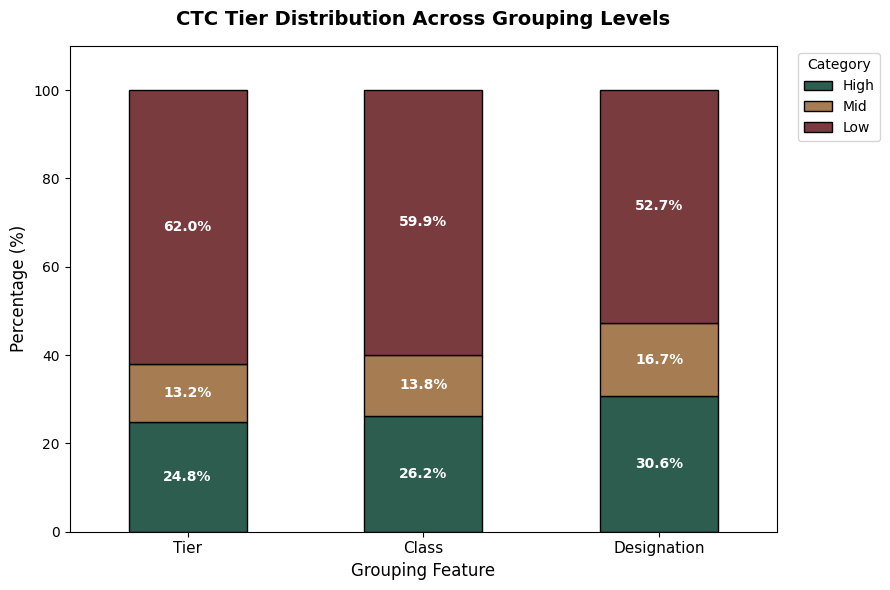

In [51]:
tier_dist = filtered_df['tier'].value_counts(normalize=True).rename(lambda x: x.split('(')[1].replace(')', '').strip()) * 100
class_dist = filtered_df['class'].value_counts(normalize=True).rename(lambda x: x.split('(')[1].replace(')', '').strip()) * 100
desig_dist = filtered_df['designation'].value_counts(normalize=True).rename(lambda x: x.split('(')[1].replace(')', '').strip()) * 100

plot_df = pd.DataFrame({
    "Tier": tier_dist,
    'Class': class_dist,
    'Designation': desig_dist
}).T[['High', 'Mid', 'Low']]

dark_mild_colors = ['#2c5d4f', '#a67c52', '#7a3b3f']
ax = plot_df.plot(kind='bar', stacked=True, figsize=(9, 6), color=dark_mild_colors, edgecolor='black', width=0.5)

plt.title('CTC Tier Distribution Across Grouping Levels', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Grouping Feature', fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.ylim(0, 100)
plt.ylim(0, 110)
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

#### **Summary:**


* **Data Cleaning & Standardization of `ctc`:** Reduced hundreds of messy job titles into 21 core roles, removed duplicate user entries, fixed invalid experience years, and removed extreme CTC outliers using log-normal bounds ($3\sigma$).
* **Hierarchical Peer Benchmarking:** Created 3 levels of peer groups to evaluate compensation:
* **Tier:** Company-wide level
* **Class:** Company + Job Role level
* **Designation:** Company + Job Role + Years of Experience level


* **$\pm 10\%$ Banding:** Assigned each learner to **High** (>110% of group mean), **Mid** (90–110% of group mean), or **Low** (<90% of group mean) by comparing their individual CTC directly to their peer group average.
* **Reliability Filtering:** Filtered out cohorts with 5 or fewer members to drop unreliable group averages.
* **Core Takeaway:** Zooming into finer peer groups (Company $\rightarrow$ Role $\rightarrow$ Experience) reduces the "Low" category percentage, narrow peer groups shift learners out of Low, but part of this is a small-sample effect rather than a genuine reassessment.


#### **Key Insights:**

* **Compensation is Heavily Right-Skewed:** Over half of all learners fall into the **Low** bucket at every level (~61.9% in Tier, ~59.9% in Class, and ~52.7% in Designation). A small number of very high earners pull group means upward, placing most employees below the average.

* **Granularity Restores Assessment Accuracy:** As peer groups become more specific (Company $\rightarrow$ Role $\rightarrow$ Experience), the percentage of **High** earners increases from 24.8% to 30.6%, and **Mid** earners grows from 13.1% to 16.7%. Many learners who look underpaid company-wide are actually compensated fairly for their exact role and experience level but it's also a part of this is a small-sample effect rather than a genuine reassessment.

* **Target Audience for Upskilling:** Learners who remain in **Designation 3 (Low)** represent software professionals genuinely underpaid relative to exact peers, making them ideal targets for career transition programs.

### **Case Study Questions:**

In [52]:
print("1. Top 10 employees earning more than most in their company — Tier 1")
tier1_learners = df_user_profile[df_user_profile['tier'] == 'Tier 1 (High)'].copy()
top10_tier1 = tier1_learners.sort_values(by='ctc', ascending=False).head(10)
display(top10_tier1[['user_id', 'company_id', 'job_position', 'years_of_exp', 'ctc', 'tier']])


print("2. Top 10 data-science employees in each company earning more than peers — Class 1")
ds_class1 = df_user_profile[(df_user_profile['job_position'].str.contains('data science|data scientist', case=False, na=False)) & (df_user_profile['class'] == 'Class 1 (High)')].copy()
top10_ds_class1 = ds_class1.sort_values(by='ctc', ascending=False).groupby('company_id', observed=True).head(10)
display(top10_ds_class1[['user_id', 'company_id', 'job_position', 'years_of_exp', 'ctc', 'class']])


print("3. Bottom 10 data-science employees in each company earning less than peers — Class 3")
ds_class3 = df_user_profile[(df_user_profile['job_position'].str.contains('data science|data scientist', case=False, na=False)) & (df_user_profile['class'] == 'Class 3 (Low)')].copy()
bottom10_ds_class3 = ds_class3.sort_values(by='ctc', ascending=True).groupby('company_id', observed=True).head(10)
display(bottom10_ds_class3[['user_id', 'company_id', 'job_position', 'years_of_exp', 'ctc', 'class']])


print("4. Bottom 10 employees earning less than most in their company — Tier 3")
tier3_learners = df_user_profile[df_user_profile['tier'] == 'Tier 3 (Low)'].copy()
bottom10_tier3 = tier3_learners.sort_values(by='ctc', ascending=True).head(10)
display(bottom10_tier3[['user_id', 'company_id', 'job_position', 'years_of_exp', 'ctc', 'tier']])


print("5. Top 10 employees per company/department with 5/6/7 years experience earning more than peers — Tier X")
tier_x_learners = df_user_profile[(df_user_profile['years_of_exp'].isin([5, 6, 7])) & (df_user_profile['tier'] == 'Tier 1 (High)')].copy()
top10_tier_x = tier_x_learners.sort_values(by='ctc', ascending=False).groupby(['company_id', 'job_position'], observed=True).head(10)
display(top10_tier_x[['user_id', 'company_id', 'job_position', 'years_of_exp', 'ctc', 'tier']])


print("6. Top 10 companies by CTC")
top10_companies_ctc = df_user_profile.groupby('company_id', observed=True)['ctc'].mean().reset_index().sort_values(by='ctc', ascending=False).head(10)
display(top10_companies_ctc)


print("7. Top 2 positions in every company by CTC")
top2_positions_per_company = df_user_profile.groupby(['company_id', 'job_position'], observed=True)['ctc'].mean().reset_index().sort_values(by=['company_id', 'ctc'], ascending=[True, False]).groupby('company_id', observed=True).head(2)
display(top2_positions_per_company)

1. Top 10 employees earning more than most in their company — Tier 1


,user_id,company_id,job_position,years_of_exp,ctc,tier
24843,2a25c3fe9dbab57df204b6d2ec7b29c4ad19a1d1d017b7...,hiotku fwkunza,fullstack devloper,4,24800000.0,Tier 1 (High)
9032,0f13d1956cced148d43023f048d26b8c9d91791ef7fad5...,wkotzw,fullstack devloper,7,24700000.0,Tier 1 (High)
16887,1c6e8458e487078ac6f26b56156de6d7ab48e33c998bf8...,fkhfdut,backend engineer,9,24600000.0,Tier 1 (High)
145135,f7b7c771ccdbbca7248002ba83f7a176baa974c2c7bb8f...,lsws,data scientist,9,24200000.0,Tier 1 (High)
51871,58ad6652cff3d7eeed67d30b084bd0df31a23cfe56a351...,lnivzo subiwzle,others,7,24000000.0,Tier 1 (High)
33268,389cf9ddc8d07c59a17c1cff09ee6687cdd7438ef40ce9...,qdnsna,engineering leadership,12,24000000.0,Tier 1 (High)
133276,e3c161c7a20c3620a5aae3ef86823b0634aadc7c0254c0...,subijdnfz,fullstack devloper,0,24000000.0,Tier 1 (High)
87009,94a12793696b2e005e26d842ef5e734ba29897b6a8b894...,liulzuwosy,others,3,24000000.0,Tier 1 (High)
100863,ac4190f02a98d4882a4c5c73bd68a4ce998bfc7519f163...,khkqiu,research engineer,0,24000000.0,Tier 1 (High)
141437,f1788f170328493a5ae4a650af5d0063123d67cf56b0e2...,khkqiu,android engineer,2,24000000.0,Tier 1 (High)


2. Top 10 data-science employees in each company earning more than peers — Class 1


,user_id,company_id,job_position,years_of_exp,ctc,class
145135,f7b7c771ccdbbca7248002ba83f7a176baa974c2c7bb8f...,lsws,data scientist,9,24200000.0,Class 1 (High)
52432,599e489c815ba51967965c5d6adefd7a76a99ffaa129bd...,hsloifibw,data scientist,17,22500000.0,Class 1 (High)
106499,b5dc6ad6d8d8f04312c34285a3c45fd9ffdc73ff3f1205...,sgh,data scientist,9,20000000.0,Class 1 (High)
75400,80f1ae60373f0ada3b75ce19eb585f8cf112de3cfa6ea7...,uku,data scientist,3,20000000.0,Class 1 (High)
142786,f3be1fa69e519e8dd93b7e3661e3bd05b6977326db8c02...,bnsjrkow,data scientist,11,19200000.0,Class 1 (High)
...,...,...,...,...,...,...
91283,9bf9105bebe78787ba318710fdfbbfbc17baff5cfe5281...,uvscsk,data scientist,14,300000.0,Class 1 (High)
110530,bcc62234411c5bdd7742a6c14a811d877cdc6f61841359...,liulzuwosy,data scientist,4,200999.0,Class 1 (High)
137852,eb8283b0eb3fc5fd386cb31567f0a0fe85d1148d50095d...,jzuu fwkwz dusvzofswa,data scientist,3,200000.0,Class 1 (High)
118745,cafbe82bdd822f80cdf232311a09fb8d8c6ccdac5786f2...,sucznnszuw,data scientist,1,180000.0,Class 1 (High)


3. Bottom 10 data-science employees in each company earning less than peers — Class 3


...

,user_id,company_id,job_position,years_of_exp,ctc,tier
9032,0f13d1956cced148d43023f048d26b8c9d91791ef7fad5...,wkotzw,fullstack devloper,7,24700000.0,Tier 1 (High)
51871,58ad6652cff3d7eeed67d30b084bd0df31a23cfe56a351...,lnivzo subiwzle,others,7,24000000.0,Tier 1 (High)
67277,730cc9e861791b0e652875a3487ced91434340a0224ada...,lnivzo subiwzle,backend engineer,7,24000000.0,Tier 1 (High)
145566,f867042d9a6413d7315eb0123b18caa62c1bc7fa9d3ce4...,riwkr hkesucok gkur,frontend developer,7,23650000.0,Tier 1 (High)
99494,a9f77afdacebe7050a98e12cb0271d543fc13cb4869fd4...,gkur ib khzoslk,others,5,22300000.0,Tier 1 (High)
...,...,...,...,...,...,...
84439,9051d086afb0d1edc3afcc18d08298063d2c23c0bd1ef1...,c2fin sul,backend engineer,5,143000.0,Tier 1 (High)
79270,87928a88e94e306901e85de2b3ce1d861c616a7ad0854e...,hzwsf,data scientist,6,120000.0,Tier 1 (High)
136447,e92edcc7f6f4803e4c4297086bda2233b2a4ea0c5b6658...,wosnita zcdlkwsiu fzovslzf sul,fullstack devloper,5,115000.0,Tier 1 (High)
129264,dceec624080f24116e1591606b7a52984c3d388af7702e...,fitzws,backend engineer,5,95000.0,Tier 1 (High)


6. Top 10 companies by CTC


,company_id,ctc
32942,wzykd kdwihkwz aido nzkc tzuzokwsiu,24500000.0
31110,wez krfekakjkwok biduckwsiu,24500000.0
9912,hgfs lioj,24000000.0
24198,rkhodj linnztz ib vilkwsiukn woksusut,24000000.0
24963,sfekuak sucsk biduckwsiu,24000000.0
33930,zgokucvkndz,23800000.0
28830,ukukuuk,23000000.0
26638,suwznnf nzkousut,22450000.0
22349,okpkw ktoi lihhicswszf jvw nwc,22400000.0
32600,wzlesuslkn woksuzo,22000000.0


7. Top 2 positions in every company by CTC


,company_id,job_position,ctc
0,0,frontend developer,100000.0
1,0000,others,300000.0
3,01 fauzota,frontend developer,830000.0
2,01 fauzota,android engineer,270000.0
4,05gu bsuezknwe josvkwz nshswzc,others,1100000.0
...,...,...,...
57880,zzhjekfaf nwc,ios engineer,1526000.0
57881,zzhzqz fibw wzle,frontend developer,1000000.0
57882,zzm wzleuinitszf,devops engineer,800000.0
57883,zzqansbz sul,fullstack devloper,710000.0


## Feature Engineering 

In [53]:
filtered_df["company_mean_ctc"] = filtered_df.groupby("company_id", observed=True)["ctc"].transform("mean")
filtered_df["job_mean_ctc"] = filtered_df.groupby("job_position", observed=True)["ctc"].transform("mean")

filtered_df["class_mean"] = filtered_df.groupby(["company_id", "job_position"], observed=True)["ctc"].transform("mean")
filtered_df["designation_mean"] = filtered_df.groupby(['company_id', 'job_position', 'years_of_exp'], observed=True)["ctc"].transform("mean")

filtered_df["tier_ratio"] = filtered_df["ctc"] / filtered_df["company_mean_ctc"]
filtered_df["class_ratio"] = filtered_df["ctc"] / filtered_df["class_mean"]
filtered_df["designation_ratio"] = filtered_df["ctc"] / filtered_df["designation_mean"]

filtered_df.columns

Index(['user_id', 'company_id', 'job_position', 'org_year', 'years_of_exp',
       'ctc', 'ctc_change', 'ctc_updated_year', 'total_updates', 'ctc_log',
       'tier_group_size', 'class_group_size', 'designation_group_size', 'tier',
       'class', 'designation', 'company_mean_ctc', 'job_mean_ctc',
       'class_mean', 'designation_mean', 'tier_ratio', 'class_ratio',
       'designation_ratio'],
      dtype='object')

In [54]:
basic_features = ["ctc_log", "years_of_exp", "company_mean_ctc", "class_ratio"]

all_features = [ 'years_of_exp', 'ctc_change', 'ctc_log', 'tier_group_size', 'class_group_size', 'designation_group_size', 'company_mean_ctc', 'tier_ratio', 'class_ratio', 'designation_ratio']

only_numeric_features = ["years_of_exp", "ctc_log"]

### Feature Engineering Summary

**1. Dimensionality Reduction & Feature Selection**

* **Dropped `org_year`:** Correctly removed to prevent multicollinearity, as it has a near-perfect inverse correlation ($-0.95$) with `years_of_exp`.
* **Dropped `total_updates` & `ctc_updated_year`:** Removed to reduce noise. `total_updates` showed $\approx 0$ correlation with other variables, and `ctc_updated_year` is an administrative timestamp rather than a meaningful professional attribute.
* **Mean Encoding for Categoricals:** Replaced the highly cardinal `company_id` (35k unique categories) with `company_mean_ctc`. This avoids the "curse of dimensionality" that would occur with One-Hot Encoding, which creates massive, sparse matrices that ruin Euclidean distance calculations.

**2. Feature Transformation & Creation**

* **Log Transformation (`ctc_log`):** Applied to normalize the highly right-skewed salary data, allowing K-Means to cluster based on proportional differences rather than being skewed by extreme outliers.
* **Relative Ratios (`class_ratio`, tier ratios):** Built to capture relative standing (performance/pay within a peer group). Since manual clustering showed that relative pay behaves differently than absolute pay, these ratios ensure K-Means groups learners by their peer-relative characteristics.

**3. Clustering Strategy & Subsets**

"Because K-Means is a distance-based algorithm that assigns equal weight to all features, it is highly sensitive to the scale of the data. To prevent high-magnitude variables (like raw CTC) from dominating the cluster formation, we are experimenting with structured inputs across distinct feature subsets:"

* **Basic Features:** Stripped down to fundamental metrics (e.g., focusing on just two core numeric features like experience and log-CTC) and explicitly removing raw CTC-related columns so they don't overpower the Euclidean distance calculations.

* **All-Focused Features:** A robust set of 10 engineered features derived from the manual clustering phase (including 3 ratios, 3 means, and group sizes)

* **Only Numeric Features:** Contain only two numeric features. 

## K-means Clustering

#### Preprocessing 

In [55]:
from sklearn.preprocessing import StandardScaler

X1 = filtered_df[basic_features]
X2 = filtered_df[all_features]
X3 = filtered_df[only_numeric_features]

scaler = StandardScaler()

X1 = scaler.fit_transform(X1)
X2 = scaler.fit_transform(X2)
X3 = scaler.fit_transform(X3)

#### Hypermeter Tuning - Elbow Method & Feature selection 

In [56]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_list = [X1,X2,X3]

K = range(2,11)
silhouette_scores = []

for X in X_list:
    for k in K:
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init="auto")
        cluster_labels = kmeans.fit_predict(X)

        score = silhouette_score(X, cluster_labels)
        silhouette_scores.append((k,score))
        print(f"For K = {k} and No. of Feats:{X.shape[1]} Silhouette Score is {score:.4f}")

For K = 2 and No. of Feats:4 Silhouette Score is 0.3783
For K = 3 and No. of Feats:4 Silhouette Score is 0.3766
For K = 4 and No. of Feats:4 Silhouette Score is 0.3550
For K = 5 and No. of Feats:4 Silhouette Score is 0.3003
For K = 6 and No. of Feats:4 Silhouette Score is 0.2826
For K = 7 and No. of Feats:4 Silhouette Score is 0.2969
For K = 8 and No. of Feats:4 Silhouette Score is 0.2836
For K = 9 and No. of Feats:4 Silhouette Score is 0.2774
For K = 10 and No. of Feats:4 Silhouette Score is 0.2843
For K = 2 and No. of Feats:10 Silhouette Score is 0.2313
For K = 3 and No. of Feats:10 Silhouette Score is 0.2294
For K = 4 and No. of Feats:10 Silhouette Score is 0.2247
For K = 5 and No. of Feats:10 Silhouette Score is 0.2187
For K = 6 and No. of Feats:10 Silhouette Score is 0.2421
For K = 7 and No. of Feats:10 Silhouette Score is 0.2441
For K = 8 and No. of Feats:10 Silhouette Score is 0.2153
For K = 9 and No. of Feats:10 Silhouette Score is 0.1957
For K = 10 and No. of Feats:10 Silhouet

In [57]:
best_k, best_score = max(silhouette_scores, key=lambda item: item[1])

print(f"Best K: {best_k} with Silhouette Score: {best_score:.4f}")

Best K: 2 with Silhouette Score: 0.3807


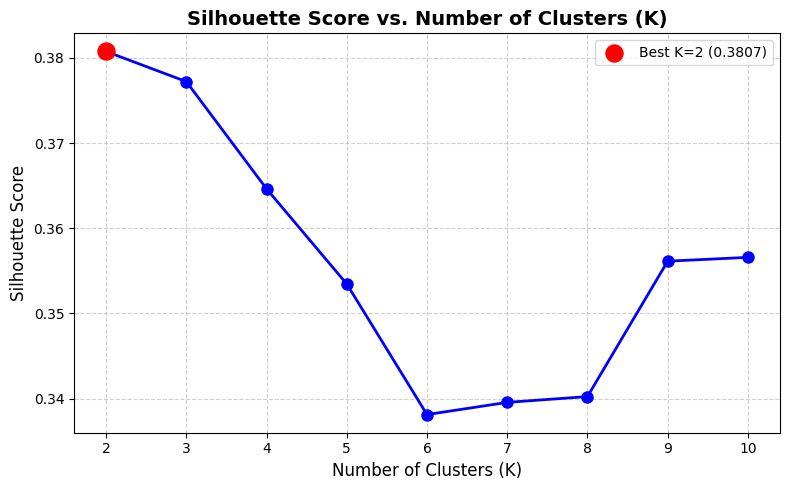

In [58]:
K = range(2,11)
elbow_method_silhouette_score = [] 

for k in K:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init="auto")
    cluster_labels = kmeans.fit_predict(X3)

    score = silhouette_score(X3, cluster_labels)
    elbow_method_silhouette_score.append((k,score))

ks, scores = zip(*elbow_method_silhouette_score)

plt.figure(figsize=(8, 5))
plt.plot(ks, scores, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

max_idx = scores.index(max(scores))
plt.scatter(ks[max_idx], scores[max_idx], color='red', s=150, zorder=5, label=f'Best K={ks[max_idx]} ({scores[max_idx]:.4f})')

plt.title('Silhouette Score vs. Number of Clusters (K)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(ks)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best')

plt.tight_layout()
plt.show()

#### Best K-means Model & Visualization

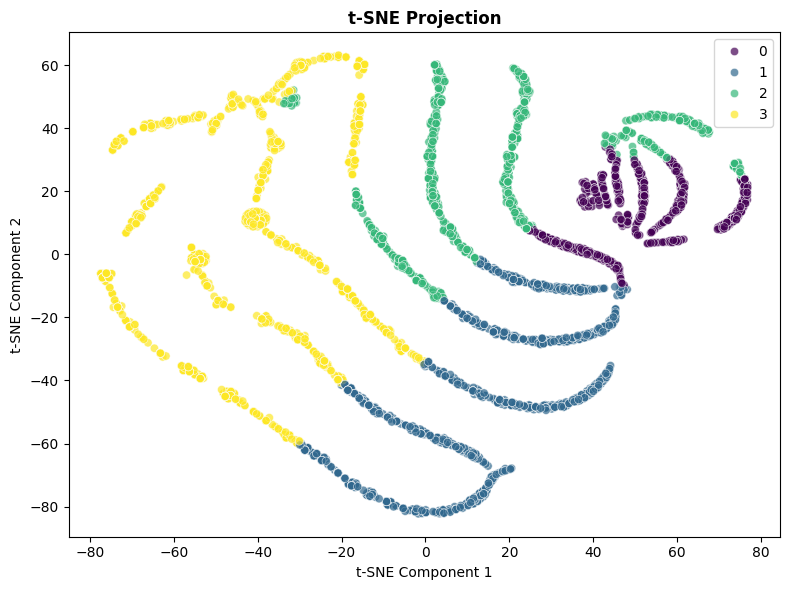

In [59]:
from sklearn.manifold import TSNE

kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(X3)

sample_size = int(0.1 * len(cluster_labels))
np.random.seed(42)
sample_indices = np.random.choice(len(cluster_labels), size=sample_size, replace=False)

X_sample = X3[sample_indices] if isinstance(X3, np.ndarray) else X3.iloc[sample_indices]
labels_sample = cluster_labels[sample_indices]

tsne = TSNE(n_components=2, perplexity=40, random_state=42, init='pca', learning_rate='auto')
tsne_results = tsne.fit_transform(X_sample)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=tsne_results[:, 0], 
    y=tsne_results[:, 1],
    hue=labels_sample,
    palette="viridis",
    alpha=0.7
)

plt.title('t-SNE Projection', fontweight='bold')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

plt.tight_layout()
plt.show()

In [60]:
filtered_df["cluster"] = cluster_labels
filtered_df.groupby('cluster').agg({'ctc':'median','years_of_exp':'median','user_id':'count'})

,ctc,years_of_exp,user_id
cluster,,,
0,2000000.0,7.0,5878
1,1760000.0,2.0,11478
2,700000.0,4.0,9721
3,430000.0,1.0,14668


### Key Takeaways: K-Means & Silhouette Analysis

**1. The Metric Spread is Noise (Axis Scaling Illusion)**

* The Silhouette Score across all tested $K$ values ranges strictly between **0.338 and 0.381**—a negligible spread of just **0.043**.
* The dramatic drop seen on the plot is an illusion caused by narrow axis scaling. Plotted on a standard $0$ to $1$ scale, the curve is essentially flat. The Silhouette Score fails to meaningfully discriminate between $K$ values because no single $K$ is mathematically superior.

**2. Signature of Continuous Manifolds (Ribbon-like Trajectories)**

* A peak score of $\approx 0.38$ at $K=2$ aligns with the t-SNE visualization, which reveals continuous, elongated "ribbons" or "strings" rather than distinct, globular clouds.
* Because K-Means enforces spherical distance boundaries, it arbitrarily slices these continuous manifolds into rigid segments (yielding low silhouette scores below $0.50$). This confirms earlier EDA findings that career progression exists along a continuous spectrum rather than isolated clusters.

**3. Feature Dilution (Curse of Dimensionality)**

* Simpler inputs (2 core features) consistently scored higher than richer feature sets (10 features).
* Adding dimensions diluted the Euclidean distance metrics with extra noise rather than sharpening cluster boundaries, confirming that lower-dimensional projections preserve spatial geometry better for distance-based algorithms.


### Strategic Decision: Grounding Clusters in Data ($K=4$)

While $K=2$ technically yields the highest score, splitting learners into simple "High Pay" and "Low Pay" groups provides no actionable business value. Selecting **$K=4$** reveals distinct, highly actionable career archetypes grounded directly in our aggregate statistics:

* **Cluster 0 — Senior, Well-Paid (Median CTC: ₹20.0L | Exp: 7.0 yrs | $N = 5,878$):** Established senior talent earning top-tier market compensation.
* **Cluster 1 — Fast Risers (Median CTC: ₹17.6L | Exp: 2.0 yrs | $N = 11,478$):** High-velocity tech talent commanding near-senior compensation in just a third of the tenure. This group represents Scaler’s strongest marketing proof-point for rapid career acceleration.
* **Cluster 2 — Mid-Career, Market-Rate (Median CTC: ₹7.0L | Exp: 4.0 yrs | $N = 9,721$):** Mid-level professionals progressing along standard industry benchmarks.
* **Cluster 3 — Early Career (Median CTC: ₹4.3L | Exp: 1.0 yr | $N = 14,668$):** Entry-level learners building foundational industry experience.

**Key Structural Insight:** Experience and compensation do not scale linearly. Comparing Cluster 1 to Cluster 2 reveals that learners in Cluster 1 have half the tenure yet earn **2.5× the compensation**. High pay in tech is driven significantly by skill acceleration rather than pure years in the industry.

### Next Step: Hierarchical Clustering

Since K-Means forces spherical partitioning onto continuous, ribbon-like manifolds, we now transition to **Agglomerative Hierarchical Clustering**. Inspecting dendrograms will allow us to evaluate whether bottom-up, tree-based merging better preserves these connected pathways and reveals natural nested sub-structures that Euclidean distance-partitioning missed.

## Hierarchical Clustering

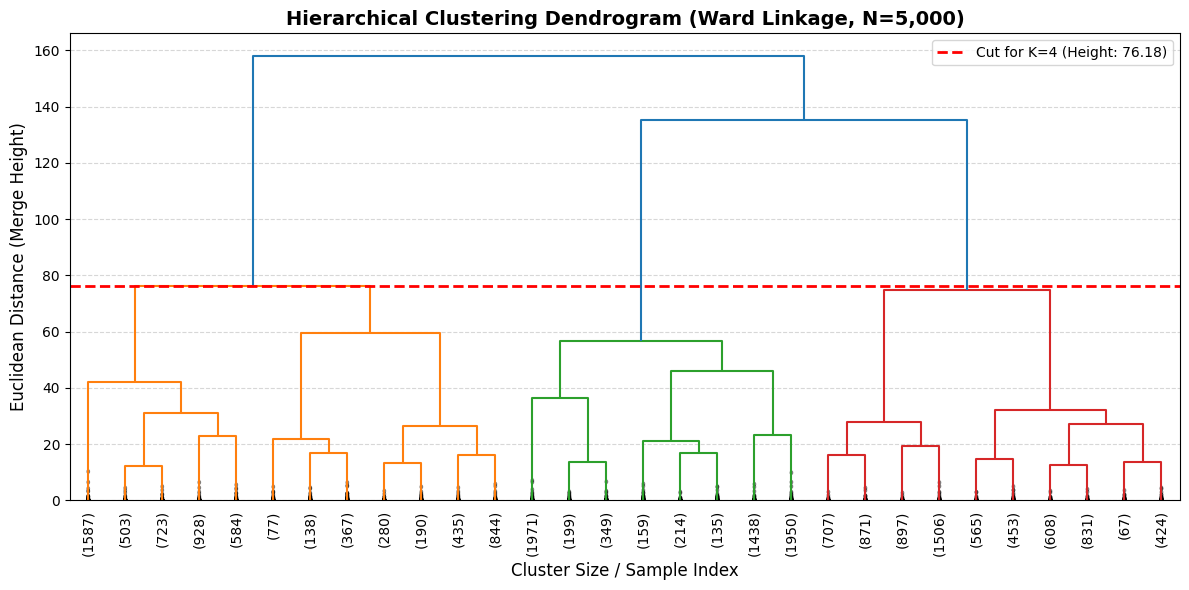

In [61]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

SAMPLE_SIZE = 20000
np.random.seed(42)

if isinstance(X3, np.ndarray):
    sample_indices = np.random.choice(X3.shape[0], size=SAMPLE_SIZE, replace=False)
    X_sample = X3[sample_indices]
else:
    X_sample = X3.sample(n=SAMPLE_SIZE, random_state=42).values

# Ward Linkage Matrix via SciPy
Z_ward = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))

# Truncate to top 30 merged branches to prevent leaf clutter
dendrogram(
    Z_ward,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

# Draw horizontal cut-line corresponding to K=4 clusters (3rd to last merge height)
k_4_threshold = Z_ward[-3, 2]
plt.axhline(y=k_4_threshold, color='r', linestyle='--', linewidth=2, label=f'Cut for K=4 (Height: {k_4_threshold:.2f})')

plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, N=5,000)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster Size / Sample Index', fontsize=12)
plt.ylabel('Euclidean Distance (Merge Height)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [62]:
linkage_methods = ['ward', 'average', 'complete', 'single']
results = []

for method in linkage_methods:
    model = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage=method)
    labels = model.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    results.append({'Linkage Method': method, 'Silhouette Score (K=4)': round(score, 4)})

df_linkage_comp = pd.DataFrame(results)
display(df_linkage_comp)

,Linkage Method,Silhouette Score (K=4)
0,ward,0.3111
1,average,0.4112
2,complete,0.2761
3,single,0.6599


In [63]:
AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage="single")
labels = model.fit_predict(X_sample)
pd.Series(labels).value_counts()

0    19996
2        2
3        1
1        1
Name: count, dtype: int64

### Hierarchical Clustering & Dendrogram Analysis

**1. Structural Topology & Cluster Cut Choice**

* The largest vertical distance jump (the tallest gap on the dendrogram, between height ~80 and ~135) indicates **2 natural macro-clusters**.
* The cut at height $76.18$ was selected to enforce **$K=4$** purely for business interpretability—maintaining consistency with our $K$-Means segmentation. Both algorithms independently demonstrate that the dataset represents a continuous career spectrum rather than well-separated, discrete groups.

**2. Linkage Selection: Ward vs. Single Linkage**

* **Single Linkage Illusion:** While single linkage produced a misleadingly high Silhouette Score ($\approx 0.66$), value counts revealed severe **chaining** (one giant cluster containing $99.98\%$ of the sample paired with three single-element outlier clusters).
* **Ward Linkage Adoption:** We explicitly selected **Ward Linkage** because minimizing within-cluster variance prevents chaining artifacts and yields balanced, actionable segments across the learner population.

**3. Hierarchical Evolution Along the Career Spectrum**

* The dendrogram’s multi-tiered, bottom-up tree structure reflects the continuous, ribbon-like geometry observed in our t-SNE projections.
* Rather than imposing rigid distance boundaries, agglomerative merging shows how localized sub-groups incrementally join adjacent tiers along the compensation and experience continuum, providing a clear visual hierarchy of learner progression.

## Anomaly Detection - Isolation Forest

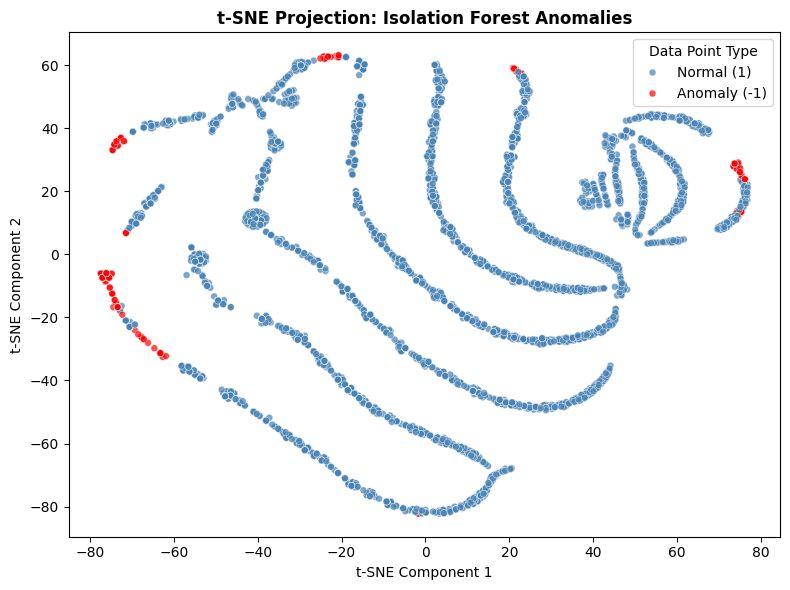

In [64]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_labels = iso_forest.fit_predict(tsne_results)

df_tsne_plot = pd.DataFrame({
    't-SNE 1': tsne_results[:, 0],
    't-SNE 2': tsne_results[:, 1],
    'Anomaly': ['Anomaly (-1)' if label == -1 else 'Normal (1)' for label in outlier_labels]
})

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_tsne_plot,
    x='t-SNE 1',
    y='t-SNE 2',
    hue='Anomaly',
    palette={'Normal (1)': 'steelblue', 'Anomaly (-1)': 'red'},
    alpha=0.7,
    s=25
)

plt.title('t-SNE Projection: Isolation Forest Anomalies', fontweight='bold')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Data Point Type')

plt.tight_layout()
plt.show()

### **Anomaly Detection (Isolation Forest)**

* **Methodology & Scope:** Applied post-hoc to scaled features (`years_of_exp`, `ctc_log`) with `contamination=0.01` (~1% flagged). Clusters were not refit, as these points represent plausible extreme profiles rather than data errors—impossible CTCs were already removed during rule-based cleaning.

* **t-SNE Spatial Distribution:** Flagged points sit almost exclusively at the far-left tips and outer edges of the projection rather than scattered through the interior. This confirms our continuum finding: anomalies manifest as boundary cases at the limits of the compensation-experience spectrum, not isolated groups.

* **Outlier Profile & Limitation:** Learners are multivariate outliers—profiles plausible in univariate isolation but atypical in combination (e.g., high CTC at low tenure or low CTC at high tenure). The primary limitation is that `contamination=0.01` is an assumed heuristic threshold, defining the extreme 1% tail by design.

## Actionable Insights & Recommendations

**1. Investigate "Fast Risers" to Replicate Success**

* **Insight:** Cluster 1 learners ("Fast Risers") command near-senior compensation (₹17.6L median) with just a third of the standard tenure (2.0 years experience). This suggests a strong hypothesis: accelerated compensation is driven by specific early-career skill acquisitions or backgrounds rather than pure time served.

* **Action:** Investigate this cohort by linking these records to internal Scaler data (e.g., modules completed, tech stacks learned, entry assessments). Identifying exactly what distinguishes these top earners will allow Scaler to construct targeted "Fast Track" learning paths and use these realistic, accelerated trajectories as authentic ROI proof-points in marketing.

**2. Target "Designation 3" Learners for Immediate Upskilling**

* **Insight:** Learners categorized as "Designation 3 (Low)" are objectively underpaid compared to peers with the *exact same role and tenure* within their own companies, making them highly aware of their compensation gap.

* **Action:** Launch highly targeted lifecycle marketing campaigns offering these specific learners advanced technical specializations, interview prep, or salary negotiation workshops. Because their compensation gap is highly quantifiable, the ROI narrative for upskilling is clear and compelling.

**3. Prioritize High-Yield Placement Partnerships**

* **Insight:** Our aggregated rankings identified the precise environments where Scaler alumni maximize their earning potential, specifically highlighting top-paying employers

* **Action:** Direct the B2B placement team to prioritize these explicit, high-paying employers and roles for hiring pipelines, alumni referral programs, and corporate training partnerships to maximize the post-course salary bumps reported by Scaler graduates.

**4. Shift to Continuous Percentile Benchmarking**

* **Insight:** K-Means, t-SNE, and Hierarchical clustering all consistently demonstrated that tech careers operate on a continuous, ribbon-like spectrum rather than falling into distinct, discrete classification buckets.

* **Action:** Redesign the Scaler learner dashboard to display compensation and skill progress as a continuous rolling percentile (e.g., "You are in the 85th percentile for 3-year Backend Engineers") rather than static tiers. This provides a more accurate, gamified, and motivating growth metric for the learner.

**5. Standardize Data Capture for Real-Time Profiling**

* **Insight:** Granular peer-to-peer analysis was severely constrained by data quality: 22% of profiles had unusable or messy job titles, and 71% of companies had only a single learner, which prevents robust intra-company benchmarking.

* **Action:** Implement strict, standardized dropdown menus for 'Job Title' and 'Company Name' (potentially leveraging a LinkedIn or Glassdoor API) during user onboarding. Cleaner data ingestion will unlock Scaler's ability to deploy automated, real-time salary benchmarking directly into the learner product.